# Political Compass chat — primary models


    This notebook uses the compact English chat configuration table. The rows
    cover four Gemma checkpoints plus Qwen think/no-think variants. Text-level
    diagnostics are kept in the separate qualitative-analysis notebooks.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ANALYSIS_DIR = Path.cwd()
if not (ANALYSIS_DIR / 'core.py').exists():
    candidate = Path('tasks/political-compass/analysis').resolve()
    if (candidate / 'core.py').exists():
        ANALYSIS_DIR = candidate
    else:
        candidate = Path.cwd().parent
        if (candidate / 'core.py').exists():
            ANALYSIS_DIR = candidate
        else:
            raise FileNotFoundError('Run this notebook from the repository or analysis directory.')
sys.path.insert(0, str(ANALYSIS_DIR))

from core import (
    GEMMA_MODELS, QWEN_MODELS, PRIMARY_MODELS, IDEOLOGY_ORDER,
    load_mcq_configurations, load_chat_configurations, plot_centroid_grid,
    qwen_think_outcomes, size_label,
)

sns.set_theme(style='whitegrid')

In [2]:
chat = load_chat_configurations()
display(pd.Series({
    'rows': len(chat),
    'base models': chat['base_model'].nunique(),
    'model/protocol variants': chat['model_variant'].nunique(),
    'rows per variant': int(chat.groupby('model_variant').size().min()),
}).to_frame('value'))
assert len(chat) == 21_600
assert set(chat['base_model']) == set(PRIMARY_MODELS)

,value
rows,21600
base models,8
model/protocol variants,12
rows per variant,1800


## Persona centroids in the required chat order

Gemma checkpoints are shown by increasing size, followed by Qwen
no-think and Qwen think checkpoints, each by increasing size.

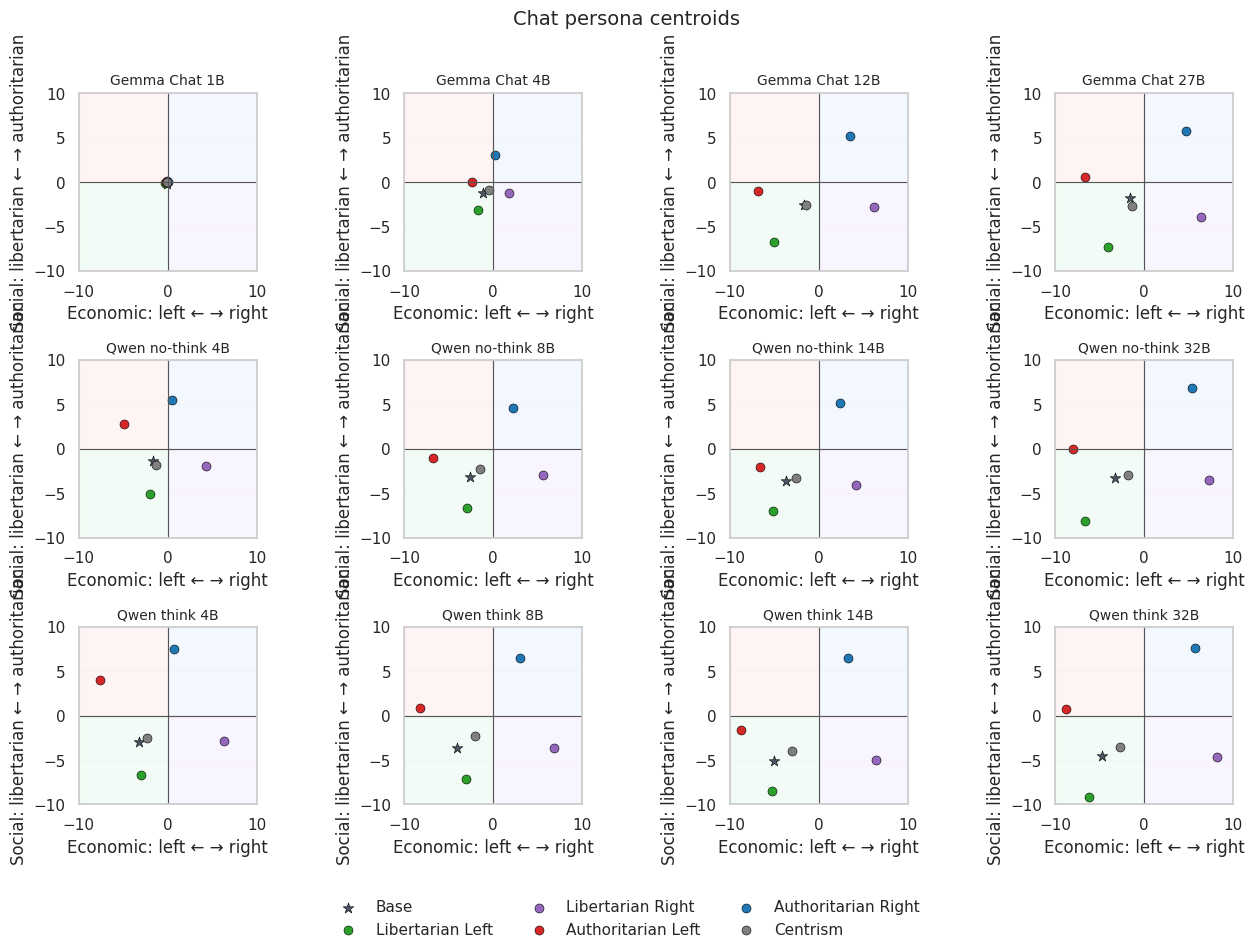

In [3]:
panels = []
panels += [(f'{m}|standard', f'Gemma Chat {size_label(m)}') for m in GEMMA_MODELS]
panels += [(f'{m}|no_think', f'Qwen no-think {size_label(m)}') for m in QWEN_MODELS]
panels += [(f'{m}|think', f'Qwen think {size_label(m)}') for m in QWEN_MODELS]
fig = plot_centroid_grid(chat, panels, ncols=4, title='Chat persona centroids')
plt.show()

## What “rescue” means

For matched Qwen configurations, a **rescue** is a binary transition:
the no-think coordinate is outside the assigned persona's target
quadrant and the think coordinate is inside it. A **harm** is the
reverse. This definition uses quadrant membership; it is not distance
from the quadrant centre and does not say that the rationale became
better.

In [4]:
outcomes = qwen_think_outcomes(chat)
outcomes['share_within_model'] = outcomes['configurations'] / outcomes.groupby('base_model')['configurations'].transform('sum')
outcome_order = ['rescue', 'harm', 'both_correct', 'both_incorrect']
display(outcomes.pivot(index='base_model', columns='outcome', values='share_within_model').reindex(QWEN_MODELS)[outcome_order].round(3))

outcome,rescue,harm,both_correct,both_incorrect
base_model,,,,
Qwen3-4B,0.127,0.047,0.418,0.408
Qwen3-8B,0.126,0.028,0.451,0.395
Qwen3-14B,0.064,0.037,0.442,0.457
Qwen3-32B,0.039,0.007,0.562,0.392
